Code to generate Supplementary figure 1 subplots

In [5]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from tqdm import trange
import seaborn as sns

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../flatten/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"

# Colors and palette (use distinct variable names to avoid accidental overwrites)\
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
very_low_color = '#CC3311'  # Red for Very Low (<50)
low_color = '#FF9A29'       # Green for Low (50-70)
high_color = '#4A7BB7'      # Blue for High (≥70)
palette_colors = [very_low_color, low_color, high_color]

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# code 2: load the datasets with pLDDT and disorder fraction information
ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
#y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")

#y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

#shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
#print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")
#list(ms_nodes.columns)

Figure Supplementary figure 1(a)
1. Create histograms to visualise average pLDDT and show cutoff at plddt category; Very Low (<50) and Low (50-70).

In [6]:
# code 3: Define cutoffs and create categorical column with consistent labels
low_cutoff = 50
high_cutoff = 70

# Filter out NaN values if any
df_s1 = ms_nodes.dropna(subset=['mean_plddt', 'N_aa_disordered', 'disorder_fraction']).copy()

# Use explicit category strings that we'll reuse consistently later
category_strings = [
    f'Very Low (<{low_cutoff})',
    f'Low ({low_cutoff}-{high_cutoff})',
    f'High (≥{high_cutoff})'
]

# Bin categories
cutoffs = [0, low_cutoff, high_cutoff, df_s1['mean_plddt'].max() + 1]
df_s1['plddt_category'] = pd.cut(df_s1['mean_plddt'], bins=cutoffs, labels=category_strings, right=False)

# Print number of proteins per category
print(f"Number of proteins per category:\n{df_s1['plddt_category'].value_counts()}")

Number of proteins per category:
plddt_category
High (≥70)        2964
Low (50-70)        853
Very Low (<50)      56
Name: count, dtype: int64


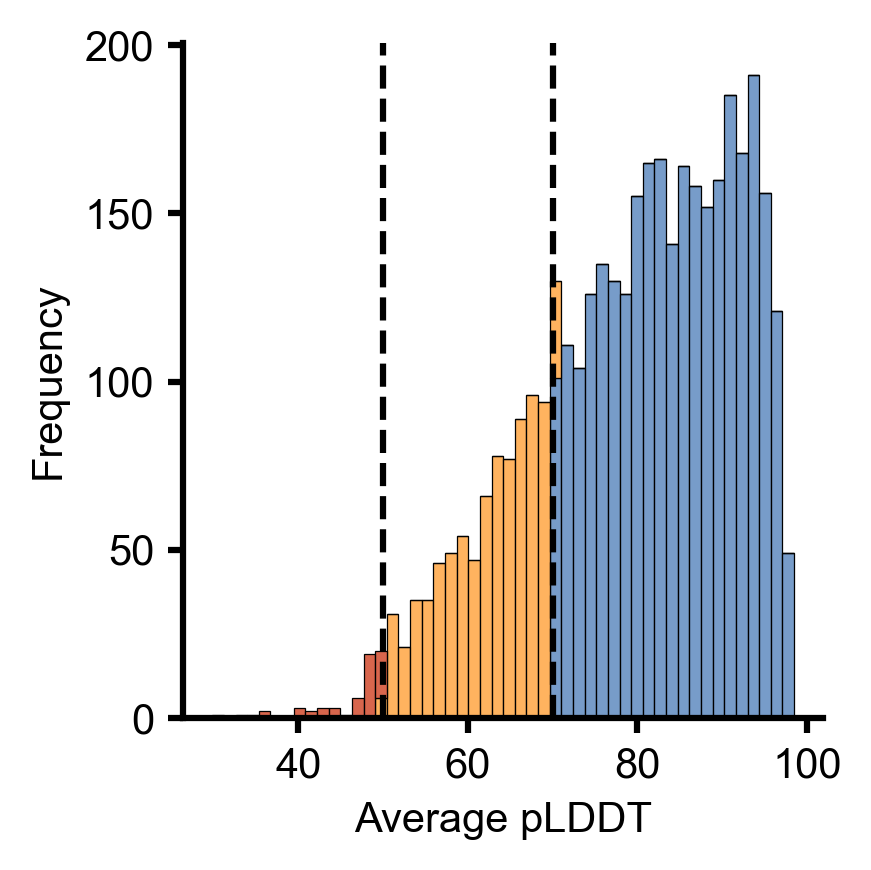

In [7]:
# code 4: plotting histogram of mean_pLDDT
fig, ax = plt.subplots(figsize=(3, 3))

# Histogram of mean_pLDDT with categories and cutoffs
sns.histplot(
    data=df_s1,
    x='mean_plddt',
    hue='plddt_category',
    multiple='stack',
    bins=50,
    ax=ax,
    palette=palette_colors
)
ax.axvline(low_cutoff, color='black', linestyle='--', label=f'Cutoff: {low_cutoff}')
ax.axvline(high_cutoff, color='black', linestyle='--', label=f'Cutoff: {high_cutoff}')
ax.set_xlabel('Average pLDDT')
ax.set_ylabel('Frequency')
ax.legend().remove()

# Make axes visually consistent
sns.despine(ax=ax)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.tick_params(width=1.5)

# Adjust layout and save
plt.tight_layout()
plt.savefig(f"{OUT_PATH}Supp-1a.svg", dpi=300, bbox_inches='tight')

Figure Supplementary figure 1
1. Create a boxplot to plddt category Very Low (<50), Low (50-70) and High (≥70) with Disorder fraction

In [11]:
# code 8: bootstrap medians for disorder_fraction (same pattern as code 5)

# Prepare data for each category (no clean_for_log needed since data is between 0 and 1 and plot is linear; just drop NaN/inf implicitly via isfinite)
very_low_vals_f = df_s1[df_s1['plddt_category'] == category_strings[0]]['disorder_fraction']
low_vals_f = df_s1[df_s1['plddt_category'] == category_strings[1]]['disorder_fraction']
high_vals_f = df_s1[df_s1['plddt_category'] == category_strings[2]]['disorder_fraction']

# Define groups with labels and colors (adapted from reference; we have three categories instead of four, and colors are category-specific)
groups_boot_fraction = [
    ("Very Low", very_low_vals_f, very_low_color),
    ("Low", low_vals_f, low_color),
    ("High", high_vals_f, high_color),
]

# Lists to store results (as in reference)
medians_fraction = []
ci_lowers_fraction = []
ci_uppers_fraction = []

# Compute and print bootstrap results for each group
for label, vals, color in groups_boot_fraction:
    m, lo, hi = bootstrap_ci_median_fraction(vals, B=1_000_000, ci=95, random_state=27)
    medians_fraction.append(m)
    ci_lowers_fraction.append(lo)
    ci_uppers_fraction.append(hi)
    print(f"{label}: median={m:.3f}, 95% CI=({lo:.3f}, {hi:.3f}), n={len(vals)})")

# Convert to arrays 
medians_fraction = np.array(medians_fraction)
ci_lowers_fraction = np.array(ci_lowers_fraction)
ci_uppers_fraction = np.array(ci_uppers_fraction)

# Convert to yerr format for Matplotlib: [lower_err, upper_err] (as in reference; though our current plot uses boxplots, this could be used if switching to point estimates with error bars)
yerr_fraction = np.vstack([medians_fraction - ci_lowers_fraction, ci_uppers_fraction - medians_fraction])

Bootstrapping medians (disorder_fraction): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 71517.94it/s]


Very Low: median=0.904, 95% CI=(0.847, 0.939), n=56)


Bootstrapping medians (disorder_fraction): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:21<00:00, 45482.35it/s]


Low: median=0.559, 95% CI=(0.541, 0.579), n=853)


Bootstrapping medians (disorder_fraction): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:46<00:00, 21447.82it/s]

High: median=0.110, 95% CI=(0.103, 0.119), n=2964)


In [12]:
# code 9: Mann–Whitney U tests for disorder_fraction
# Print medians for all categories first 
print("Medians for disorder_fraction by category:")
print(df_s1.groupby('plddt_category')['disorder_fraction'].median())

print("=== Mann–Whitney U tests on disorder_fraction (raw values) ===")
# Perform pairwise Mann-Whitney U-tests and print details for each pair
p_values_fraction = {}
for i in range(len(category_strings)):
    for j in range(i + 1, len(category_strings)):
        g1 = category_strings[i]
        g2 = category_strings[j]
        group1 = df_s1[df_s1['plddt_category'] == g1]['disorder_fraction']
        group2 = df_s1[df_s1['plddt_category'] == g2]['disorder_fraction']
        u, p = mannwhitneyu(group1, group2, alternative="two-sided")  # Added alternative="two-sided" to match reference (though it's the default)
        p_values_fraction[(g1, g2)] = p
        
        # Print details for this pair, mirroring reference structure
        print(f"\n{g1} vs {g2}")
        print(f"n({g1}) = {len(group1)}, n({g2}) = {len(group2)}")
        print(f"median({g1}) = {np.median(group1):.3f}, median({g2}) = {np.median(group2):.3f}")
        print(f"U = {u:.2f}, p = {p:.4g}")

print("Computed comparisons:", list(p_values_fraction.keys()))

Medians for disorder_fraction by category:
plddt_category
Very Low (<50)    0.904111
Low (50-70)       0.559116
High (≥70)        0.110072
Name: disorder_fraction, dtype: float64
=== Mann–Whitney U tests on disorder_fraction (raw values) ===

Very Low (<50) vs Low (50-70)
n(Very Low (<50)) = 56, n(Low (50-70)) = 853
median(Very Low (<50)) = 0.904, median(Low (50-70)) = 0.559
U = 39418.00, p = 3.191e-16

Very Low (<50) vs High (≥70)
n(Very Low (<50)) = 56, n(High (≥70)) = 2964
median(Very Low (<50)) = 0.904, median(High (≥70)) = 0.110
U = 160006.00, p = 2.672e-33

Low (50-70) vs High (≥70)
n(Low (50-70)) = 853, n(High (≥70)) = 2964
median(Low (50-70)) = 0.559, median(High (≥70)) = 0.110
U = 2342333.00, p = 0
Computed comparisons: [('Very Low (<50)', 'Low (50-70)'), ('Very Low (<50)', 'High (≥70)'), ('Low (50-70)', 'High (≥70)')]


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_36824/3896797359.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_s1.groupby('plddt_category')['disorder_fraction'].median())


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_36824/2271441387.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(group_vals_f, labels=categories_short, patch_artist=True, showfliers=False)


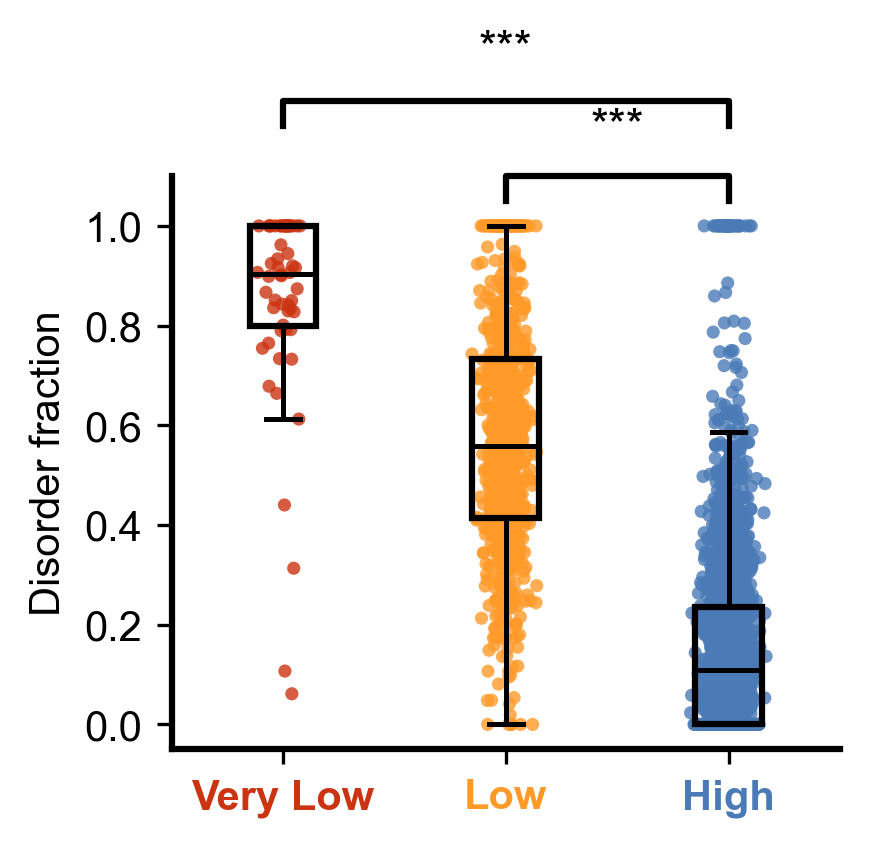

In [25]:
# code 10: plotting disorder_fraction boxplot + scatter + significance brackets
def get_sig_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'N.S.'

# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 0.05
    ax.plot([x1, x1, x2, x2], [y, y_top, y_top, y], lw=1.5, c="black", zorder=4, clip_on=False)
    ax.text((x1 + x2) / 2, y_top * 1.05, text, ha="center", va="bottom", fontsize=11, zorder=4, clip_on=False)

fig, ax = plt.subplots(figsize=(3, 3))

# Prepare data groups
categories_short = ['Very Low', 'Low', 'High']
group_vals_f = [df_s1[df_s1['plddt_category'] == cs]['disorder_fraction'] for cs in category_strings]
group_colors = palette_colors

rng = np.random.default_rng(27)
# --- Scatter first (lower zorder) ---
for i, (vals, color) in enumerate(zip(group_vals_f, group_colors), start=1):
    if len(vals) > 0:
        x_jitter = i + rng.normal(0, 0.05, size=len(vals))
        ax.scatter(x_jitter, vals, s=10, alpha=0.8, color=color, edgecolor="none", zorder=2)


# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(group_vals_f, labels=categories_short, patch_artist=True, showfliers=False)
for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)
for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# Color and bold x-tick labels
xticklabels = ax.get_xticklabels()
for i, label in enumerate(xticklabels):
    label.set_color(group_colors[i])
    label.set_fontweight('bold')

# --- Axes styling ---
ax.set_ylabel('Disorder fraction')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Add significance brackets (Very Low vs Low, Very Low vs High)
y_max = df_s1['disorder_fraction'].max()
y1 = y_max * 1.05 if np.isfinite(y_max) and y_max > 0 else 0.1
y2 = y_max * 1.2 if np.isfinite(y_max) and y_max > 0 else 0.2

p_l_h = p_values_fraction.get((category_strings[1], category_strings[2]), np.nan)
p_vl_h = p_values_fraction.get((category_strings[0], category_strings[2]), np.nan)

add_bracket_with_text(ax, 2, 3, y1, get_sig_stars(p_l_h))
add_bracket_with_text(ax, 1, 3, y2, get_sig_stars(p_vl_h))

min_y = df_s1['disorder_fraction'].min()
lower_lim = min(0, (min_y - y_max * 0.05) if np.isfinite(y_max) else -0.05)
highest_y = 1.0
ax.set_ylim(lower_lim, highest_y * 1.1)

# Adjust layout and save
plt.tight_layout()
plt.savefig(f"{OUT_PATH}Supp-1c.svg", dpi=300, bbox_inches='tight')